### Picking Arrival Times

In [75]:
import numpy as np
import xarray as xr
import netCDF4 as nc
from obspy.core.inventory import inventory
from cryoquake import data_objects as do
from cryoquake import spatial_analysis as sa
from cryoquake import event_calculation as ec
from cryoquake import moment_magnitude as mm
from obspy.core import UTCDateTime, read, Stream, Trace
import matplotlib.pyplot as plt
import obspy
from obspy.signal.filter import envelope
import multiprocessing as mp
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import tqdm
import pandas as pd
import os
from matplotlib.dates import DateFormatter, HourLocator, DayLocator
from obspy.imaging.util import _set_xaxis_obspy_dates
from matplotlib import rcParams
import plotly_resampler
import plotly.graph_objects as go
from plotly_resampler import FigureResampler, FigureWidgetResampler
from obspy.geodetics import degrees2kilometers, kilometers2degrees
from matplotlib.dates import DateFormatter, DayLocator, HourLocator
from scipy.signal import hilbert
from multitaper.mtspec import MTSine, MTSpec
from scipy.optimize import minimize
from scipy.signal.windows import get_window
from scipy.optimize import least_squares
from uncertainties import ufloat
from uncertainties.umath import cos, log10
from obspy.realtime.signal import kurtosis
import plotly.graph_objects as go
from plotly_resampler import FigureResampler, FigureWidgetResampler
from matplotlib_scalebar.scalebar import ScaleBar
from scipy.stats import chi2, norm


import pyproj
proj_wgs84 = pyproj.Proj(init="epsg:4326")
proj_epsg3031 = pyproj.Proj(init="epsg:3031")

import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from shapely.ops import transform as shp_transform


wgs84 = ccrs.PlateCarree()
stereo = ccrs.epsg(3031)


from matplotlib import rc
import matplotlib.font_manager as fm
#rc('text', usetex=True)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.sans-serif'] = 'Computer Modern'
#rc('text', usetex=True)
from matplotlib import rc
rc('font', size=8)
#rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning:

'+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning:

'+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6



In [ ]:
t1 = UTCDateTime(2018,12,24)
t2 = UTCDateTime(2019,1,30)

chunk = do.SeismicChunk(t1,t2)

path = '/Users/jmagyar/Documents/TottenData'
w_path = os.path.join(path,'stacked_waveforms')
s_path = os.path.join(path,'stations')
c_path = os.path.join(path,'catalogues')
raw_path = os.path.join(path,'waveforms')

cloud_path = '/Users/jmagyar/Library/Mobile Documents/com~apple~CloudDocs/Outputs/Icequakes'

inv_files = os.listdir(s_path)

inv = inventory.Inventory()

for file in inv_files:
    temp_path = os.path.join(s_path,file)
    inv += inventory.read_inventory(temp_path,level='response',format='STATIONXML')

#inv = inv.remove(station='TI7A')

inv = inv.select(station='TI?A',channel='CH?')

c_path = os.path.join(path,'catalogues')

temp_cat = do.EventCatalogue(t1,t2,os.path.join(c_path,'network','filtered'),templates=True)

moment_mags = chunk.load_csv(os.path.join(c_path,'network'),'moment_magnitude')
temp_cat.attributes['Mw'] = moment_mags['Mw']
groups = temp_cat.group_split()
cluster_labels = pd.read_csv(os.path.join(path,'cluster_labels' + '.csv'),index_col=0)

### Preparing Streams for Picking

In [77]:
df = 500
pol_win = 0.2 #s
freq_smooth = 20
g = 8

In [78]:
# for cluster_num in groups.keys():
#     stream = read(os.path.join(w_path,'filtered_stacked_waveforms_cluster_' + str(cluster_num) + '.mseed'))
#     #stream = stream.filter("bandpass",freqmin=1,freqmax=10) #TODO try removing response and casting as displacement waveforms which might have less noise - can do this throughout with visualisation...
#     stream = stream.select(station='TI?A')
#     stream = stream.filter("bandpass",freqmin=1,freqmax=10)
#     for tr in stream:
#         tr.stats.starttime = UTCDateTime(2019,1,10)
#         tr.remove_response(inv,output='DISP')

#     for network in inv:
#         for station in network:
#             substream = stream.select(network=network.code,station=station.code)

#             Z = substream.select(component='Z')[0]
#             N = substream.select(component='1')[0]
#             E = substream.select(component='2')[0]

#             Zm, Nm, Em = sa.RollingStreamModulation(Z.data,N.data,E.data,int(pol_win*df),g=g,smooth=freq_smooth,overlap=0.95)

#             Z.data = Zm
#             N.data = Nm
#             E.data = Em
    
#     stream.write(os.path.join(w_path,'filtered_mod_stacked_waveforms_cluster_' + str(cluster_num) + '.mseed'))

### Manual P Wave Picking

In [79]:
cluster_num = 39

stream = read(os.path.join(w_path,'filtered_mod_stacked_waveforms_cluster_' + str(cluster_num) + '.mseed'))

station = 'TI8A'

Z = stream.select(station=station,component='Z')[0]
N = stream.select(station=station,component='1')[0]
E = stream.select(station=station,component='2')[0]

fig = FigureWidgetResampler(go.Figure())
fig.add_trace(go.Scattergl(name='noisy sine', showlegend=False), hf_x=Z.times(), hf_y=Z)

fig

FigureWidgetResampler({
    'data': [{'name': ('<b style="color:sandybrown">[R' ... 'tyle="color:#fc9944">~0.04</i>'),
              'showlegend': False,
              'type': 'scattergl',
              'uid': '20fde9ea-279b-4bb2-8987-7e5df6e0072f',
              'x': array([0.0000e+00, 2.0000e-03, 5.6000e-02, ..., 3.4930e+01, 3.4996e+01,
                          3.5000e+01]),
              'y': array([ 0.00000000e+00, -9.64441740e-12, -9.56181748e-12, ..., -4.20936621e-12,
                           3.78105042e-12,  0.00000000e+00])}],
    'layout': {'template': '...'}
})

### Initial Grid Search

In [80]:
directory = '/Users/jmagyar/Documents/MappingProducts/'
bedmachine_file = directory + 'BedMachineAntarctica-v3.nc'
groundingline_file = directory + 'GroundingLine_Antarctica_v02.shp'
groundingline_file2 = directory + 'InSAR_GL_Antarctica_v02.shp'
grounding_zone = directory + 'Antarctic_GZ_2018_v01.0.shp'
coastline_file = directory + 'Coastline_Antarctica_v02.shp'
bedmap3_file = directory + 'bedmap3.nc'
bedmap3 = xr.open_dataset(bedmap3_file, engine="netcdf4")

hydrology_file = directory + 'hydrology_outputs_ll.nc'

hydrology_data = xr.open_dataset(hydrology_file, engine="netcdf4")

In [81]:
xmin = 2.2615e6
xmax = 2.2735e6
ymin = -1.0060e6
ymax = -0.9940e6

resolution = 25 #m

xlin = np.mgrid[xmin:xmax:resolution]
ylin = np.mgrid[ymin:ymax:resolution]

V = 3870 #m/s est
dV = 100 #m/s std

Delta = 10000 #m

In [82]:
#make a dataset with these coordinates...
bed_grid = xr.Dataset(coords=dict(x=("x", xlin),y=("y", ylin)))
bedmap_interp = bedmap3.interp_like(bed_grid)
ep_interp = hydrology_data.interp_like(bed_grid)
bed_grid = bed_grid.assign(dict(bed_topography = bedmap_interp.bed_topography,effective_pressure=ep_interp.effective_pressure,sheet_thickness=ep_interp.sheet_thickness,bed_uncertainty=bedmap_interp.bed_uncertainty))

In [83]:
p_picks = pd.read_csv(os.path.join(path,'stacked_waveforms','manual_picks_' + str(cluster_num) + '.csv'),index_col=0)

In [84]:
p_picks['mu'] = p_picks['P1'] + (p_picks['P2'] - p_picks['P1'])/2
p_picks['sigma'] = (p_picks['P2'] - p_picks['P1'])/4
p_picks

,P1,P2,mu,sigma
Station,,,,
TI1A,10.20,10.79,10.495,0.1475
TI3A,8.86,9.01,8.935,0.0375
TI4A,10.04,10.20,10.120,0.0400
TI6A,8.32,8.57,8.445,0.0625
TI7A,13.60,15.20,14.400,0.4000
TI8A,9.66,9.98,9.820,0.0800


In [85]:
grounding_zone_data = shpreader.Reader(grounding_zone)

groundingline_file2 = directory + 'InSAR_GL_Antarctica_v02.shp'
groundingline_data2 = shpreader.Reader(groundingline_file2)


up = []
dn = []
isl = []
for record in grounding_zone_data.records():
    if (record.attributes['Boundary'] == 'Up') & (record.attributes['Type'] == 'Ice Sheet'):
        up.append(record)
    if (record.attributes['Boundary'] == 'Dn') & (record.attributes['Type'] == 'Ice Sheet'):
        dn.append(record)
    if ((record.attributes['Type'] == 'Island') | (record.attributes['Type'] == 'EIR')):
        isl.append(record)

from pyproj import Transformer

to_wgs84 = Transformer.from_crs("EPSG:3031", "EPSG:4326", always_xy=True).transform
to_epsg3031 = Transformer.from_crs("EPSG:4326","EPSG:3031", always_xy=True).transform

def reproject_geom(geom):
    """Reproject a shapely geometry from EPSG:3031 to EPSG:4326."""
    return shp_transform(to_wgs84, geom)

def reverse_reproject_geom(geom):
    """Reproject a shapely geometry from EPSG:3031 to EPSG:4326."""
    return shp_transform(to_epsg3031, geom)

up_ll = [reproject_geom(rec.geometry) for rec in up]
dn_ll = [reproject_geom(rec.geometry) for rec in dn]
isl_ll = [reproject_geom(rec.geometry) for rec in isl]

In [86]:
up_xy = [rec.geometry for rec in up]
sta_xy, D, sta_lst = sa.EPSGStations(inv)

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning:

'+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning:

'+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6

/Users/jmagyar/Documents/icequakecode/cryoquake/src/cryoquake/spatial_analysis.py:644: FutureWarning:

This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1



In [87]:
#make plot with result for each level of assumptions...still worth including covariances, even if only to show that they are negligable compared to the other errors...

#first need to make the inversion a function and have the error sources as boolian arguments.

def DistXr(inv,bed_grid):
    xlin = bed_grid.x.to_numpy()
    ylin = bed_grid.y.to_numpy()
    d = xr.Dataset(coords=dict(x=xlin,y=ylin))
    dz = xr.Dataset(coords=dict(x=xlin,y=ylin))

    for network in inv:
        for station in network:
            lat, lon, sta_z, = station.latitude,station.longitude,station.elevation
            sta_x, sta_y = pyproj.transform(proj_wgs84, proj_epsg3031, lon, lat)

            dX = d.x - sta_x
            dY = d.y - sta_y
            dZ = bed_grid.bed_topography - sta_z

            dz = dz.assign({station.code:np.abs(dZ)}) #difference in elevation between station and bed
                    
            dist = (dX**2 + dY**2 + dZ**2)**(0.5)

            d = d.assign({station.code:dist})
    
    sigma_D = bed_grid.bed_uncertainty * (dz / d)
    return d, sigma_D


def BedScan(inv,p_picks,bed_grid,V=3900,sigma_V=100,Delta=10000,bed_error=True,no_model_error=False):
    """
    inv: obspy inventory with the stations
    p_picks: pandas dataframe with the 95% bounds on the p arrival time.
    bed_grid: xarray with the desired x and y coordinates for the grid search, and the bed topography (with uncertainties)
    """

    xlin = bed_grid.x.to_numpy()
    ylin = bed_grid.y.to_numpy()

    d, sigma_D = DistXr(inv,bed_grid)

    

    #h = xr.Dataset(coords=dict(x=xlin,y=ylin))
    #d = xr.Dataset(coords=dict(x=xlin,y=ylin))
    #dz = xr.Dataset(coords=dict(x=xlin,y=ylin))
    gamma = xr.Dataset(coords=dict(x=xlin,y=ylin))

    # for network in inv:
    #     for station in network:
    #         lat, lon, sta_z, = station.latitude,station.longitude,station.elevation
    #         sta_x, sta_y = pyproj.transform(proj_wgs84, proj_epsg3031, lon, lat)

    #         dX = h.x - sta_x
    #         dY = h.y - sta_y
    #         dZ = bed_grid.bed_topography - sta_z

    #         dz = dz.assign({station.code:np.abs(dZ)}) #difference in elevation between station and bed
            
            
    #         dist = (dX**2 + dY**2 + dZ**2)**(0.5)
    #         tt = dist / V #TODO change this to global variable Vp

    #         d = d.assign({station.code:dist})
    #         h = h.assign({station.code:tt})

    h = d / V

    if ~bed_error:
        sigma_D = 0.0 * sigma_D

    sta_xy, D, sta_lst = sa.EPSGStations(inv)

    #turn the above picks and uncertainties into arrays and mark missing data
    mu_P = np.zeros(len(sta_lst))
    sigma_P = np.zeros(len(sta_lst))
    pick_ind = np.full(len(sta_lst),fill_value=True)
    pick_sta = []
    for i, sta_code in enumerate(sta_lst):
        mu_P[i] = p_picks['mu'][sta_code]
        sigma_P[i] = p_picks['sigma'][sta_code]

        if np.isnan(p_picks['mu'][sta_code]):
            pick_ind[i] = False
        else:
            pick_sta.append(sta_code)

    mu_P = mu_P[pick_ind]
    sigma_P = sigma_P[pick_ind]
    D = D[pick_ind,:][:,pick_ind]
    N = np.sum(pick_ind) #number of stations where we have picks

    C_t = np.zeros((xlin.size,ylin.size,N,N))
    C_T = np.zeros((xlin.size,ylin.size,N,N))

    for i_s, sta_i in enumerate(pick_sta):

        C_t[:,:,i_s,i_s] += sigma_P[i_s]**2 #include the picking error to the diagonals

        for j_s, sta_j in enumerate(pick_sta):
            
            h_i = h.variables[sta_i].to_numpy()
            h_j = h.variables[sta_j].to_numpy()

            D_i = d.variables[sta_i].to_numpy()
            D_j = d.variables[sta_j].to_numpy()

            sigma_D_i = sigma_D.variables[sta_i].to_numpy()
            sigma_D_j = sigma_D.variables[sta_j].to_numpy()

            rho_D = 1.0
            rho_V = np.exp(-0.5 * D[i_s,j_s]**2 / (Delta**2))

            if i_s == j_s:
                rho_DV = 1.0
            else:
                rho_DV = 0.0
            
            C_T[:,:,i_s,j_s] = h_i * h_j * (((rho_D * sigma_D_i * sigma_D_j) / (D_i * D_j))**2 + 
                                            ((rho_DV * sigma_D_i * sigma_V) / (D_j * V))**2 +
                                            ((rho_DV * sigma_D_j * sigma_V) / (D_i * V))**2 + 
                                            ((rho_V * sigma_V**2)/(V**2))**2)**(0.5)

    

    if no_model_error:
        C = C_t
    else:
        C = C_t + C_T

    P = np.linalg.inv(C) # N x M x S x S

    p = np.sum(P,axis=2)
    K = np.sum(P,axis=(2,3))

    t_ave = np.zeros((xlin.size,ylin.size,N))
    h_ave = np.zeros((xlin.size,ylin.size,N))

    for j, sta_code in enumerate(pick_sta):
        t_ave[:,:,j] = (p[:,:,j] * mu_P[j]) / K

        h_ave[:,:,j] = (p[:,:,j] * h.variables[sta_code].to_numpy()) / K
        
    t_ave = t_ave.sum(axis=2)
    h_ave = h_ave.sum(axis=2)

    t_tilde = np.zeros((xlin.size,ylin.size,N))
    h_tilde = np.zeros((xlin.size,ylin.size,N))

    for i, sta_code in enumerate(pick_sta):
        t_tilde[:,:,i] = mu_P[i] - t_ave
        h_tilde[:,:,i] = h.variables[sta_code].to_numpy() - h_ave

    resid = t_tilde - h_tilde
    res = np.squeeze(P @ resid[:,:,:,None]) # N x M x S
    misfit = np.squeeze(resid[:,:,None,:] @ res[:,:,:,None]) #resid is N x M x S
    gamma_arr = (N-2) * (misfit - misfit.min()) / misfit.min() #compute the contour function from the misfit.

    #convert gamma to a xarray dataarray...

    gamma = gamma.assign({'gamma':(('x','y'),gamma_arr), 'chi2':(('x','y'),misfit)})

    #work out t0 for the optimal solution and attach this to the dataset

    x_ind, y_ind = np.unravel_index(np.argmin(gamma_arr),gamma_arr.shape)
    x0 = xlin[x_ind]
    y0 = ylin[y_ind]    
    
    fit = h_tilde[x_ind,y_ind,:] + t_ave[x_ind,y_ind]

    h_fit = np.zeros(N)


    chi2_norm = (misfit / misfit.min()) * (N-2) 
    pdf = chi2.pdf(chi2_norm,N-2) #get the unnormalised pdf structure
    pdf /= pdf.sum()
    pdf_flat = pdf.flatten()


    for i, sta_code in enumerate(pick_sta):
        gamma.attrs['D_'+sta_code] = d.isel(x=x_ind,y=y_ind).variables[sta_code].values
        gamma.attrs['t_'+sta_code] = d.isel(x=x_ind,y=y_ind).variables[sta_code].values / V
        h_fit[i] = h.isel(x=x_ind,y=y_ind).variables[sta_code].values

        r_i = d.variables[sta_code]

        r_i_flat = r_i.to_numpy().flatten()

        ind_sort = np.argsort(r_i_flat)

        r_i_sort = r_i_flat[ind_sort]
        chi2_sort = pdf_flat[ind_sort]

        cdf_r = np.cumsum(chi2_sort)
        cdf_r /= cdf_r[-1]

        ci = r_i_sort[(cdf_r >= 0.025) & (cdf_r <= 0.975)]
        sigma = (ci[-1] - ci[0]) / 4
        gamma.attrs['dD_'+sta_code] = sigma


    t0 = np.mean(fit - h_fit) #all these values are actually the same (as they should be)

    gamma.attrs['t0'] = t0
    gamma.attrs['x0'] = x0
    gamma.attrs['y0'] = y0


    pdf_x = np.sum(pdf,axis=1)
    cdf_x = np.cumsum(pdf_x)
    ci_x = xlin[(cdf_x >= 0.025) & (cdf_x <= 0.975)]
    sigma_x = (ci_x[-1] - ci_x[0]) / 4

    pdf_y = np.sum(pdf,axis=0)
    cdf_y = np.cumsum(pdf_y)
    ci_y = ylin[(cdf_y >= 0.025) & (cdf_y <= 0.975)]
    sigma_y = (ci_y[-1] - ci_y[0]) / 4

    gamma.attrs['dx'] = sigma_x
    gamma.attrs['dy'] = sigma_y

    gamma.attrs['stations'] = pick_sta


    gamma = gamma.assign({'pdf':(('x','y'),pdf)})

    return gamma

In [88]:
gamma_cov = BedScan(inv,p_picks,bed_grid,V=3870,sigma_V=50,Delta=10000,bed_error=True,no_model_error=False)
#gamma_simple = BedScan(inv,p_picks,bed_grid,V=3870,sigma_V=50,Delta=10000,bed_error=True,no_model_error=True)

/var/folders/z4/gw28hj796zjdxt4nltp_h5g1m6cl00/T/ipykernel_98348/2207695845.py:14: FutureWarning:

This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning:

'+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning:

'+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6

/Users/jmagyar/Documents/icequakecode

In [89]:
stream = read(os.path.join(w_path,'filtered_stacked_waveforms_cluster_' + str(cluster_num) + '.mseed'))
#stream.filter('bandpass',freqmin=1,freqmax=10)
stream = stream.select(station='TI?A')
for tr in stream:
    tr.stats.starttime = UTCDateTime(2019,1,10)
    tr.remove_response(inv,output='DISP')

In [90]:
arrivals = mm.Misfit2Arrivals(gamma_cov)
mm.StationMomentMagnitude(stream,arrivals,freqmin=1,freqmax=10)

,logomega0,fc,t_star,dlogomega0,dfc,dt_star,M0,dM0,Mw,dMw
TI4A,-19.340444,3.454687,0.199250,0.406483,6.905903,0.221686,7.561382e+10,4.658796e+10,1.252401,0.178388
TI3A,-19.879524,4.225607,0.112591,0.243796,5.583839,0.115648,6.032484e+10,3.166515e+10,1.186997,0.151977
TI8A,-19.686068,3.604006,0.163826,0.462452,8.596616,0.249491,4.959329e+10,3.252320e+10,1.130282,0.189873
TI6A,-19.288342,3.945783,0.157709,0.521266,10.441988,0.254284,9.136734e+10,6.394080e+10,1.307194,0.202619
TI1A,-20.110667,3.051652,0.196977,0.199567,3.043882,0.123981,5.406078e+10,2.724699e+10,1.155255,0.145925
TI7A,-19.509400,2.977841,0.276587,0.457310,6.446959,0.282564,1.117655e+11,7.264769e+10,1.365539,0.188195


In [91]:
for tr in stream.select(component='Z'):
    P_win = tr.slice(tr.stats.starttime + arrivals['P_start'][tr.stats.station],tr.stats.starttime + arrivals['P_end'][tr.stats.station])
    P_energy = np.sqrt(np.sum((tr.data**2 * tr.stats.sampling_rate)))
    print(tr.stats.station,P_energy)

TI1A 3.648764212968697e-06
TI3A 7.086854140323474e-06
TI4A 6.3714737453478636e-06
TI6A 1.0647705073447525e-05
TI7A 2.8332425121247835e-06
TI8A 5.530251953151214e-06


In [92]:
for event in groups[cluster_num]:
    event.attach_waveforms(inv,raw_path,buffer=10,length=25)
    event.filter('bandpass',freqmin=1,freqmax=10)
    stream = event.get_data_window()
    for tr in stream.select(component='Z'):
        tr.stats.starttime = UTCDateTime(2019,1,10)
        tr.remove_response(inv,output='DISP')
        P_win = tr.slice(tr.stats.starttime + arrivals['P_start'][tr.stats.station],tr.stats.starttime + arrivals['P_end'][tr.stats.station])
        P_energy = np.sqrt(np.sum((tr.data**2 * tr.stats.sampling_rate)))
        print(tr.stats.station,P_energy)
    break

TI4A 6.177434361034446e-06
TI3A 6.289107797918049e-06
TI8A 5.769986612852952e-06
TI6A 9.678846559578658e-06
TI1A 1.2561330846975605e-05
TI7A 4.8057263380431886e-06


In [93]:
P_win

1J.TI7A..CHZ | 2019-01-10T00:00:14.316000Z - 2019-01-10T00:00:22.726000Z | 500.0 Hz, 4206 samples

In [94]:
f_dict, Pxx_dict, ci_dict, err_dict = mm.SourceSpectrum(stream,arrivals,freqmin=1,freqmax=10)
results = mm.FitBruneModel(f_dict,Pxx_dict,err_dict,arrivals,1,10)

In [95]:
results

{'TI4A': (array([-19.71940906,   1.12084954,   0.14732275]),
  array([[0.01875888, 0.08898424, 0.01116386],
         [0.08898424, 0.52773801, 0.06257169],
         [0.01116386, 0.06257169, 0.00753365]]),
  {'fvec': array([ 1.81072840e-10,  1.74251594e-10,  3.00168197e-11, -5.61156999e-11,
          -1.79271556e-10, -1.68356569e-10, -3.28093787e-10, -1.63354354e-10,
          -7.26541160e-11, -3.39992878e-11,  1.74116747e-10,  1.09887040e-10,
           1.14833314e-10,  1.07586175e-10,  5.97262566e-11,  3.51588223e-11,
          -2.24065965e-12, -2.42357088e-11, -4.65672164e-11, -5.00030514e-11,
           8.09031848e-12,  8.78768907e-11,  1.09289609e-10,  1.05604554e-10,
           8.35726989e-11,  8.00036512e-11,  5.97271173e-11,  4.71834950e-11,
           3.88938243e-11,  3.34909456e-11,  1.61816356e-11,  2.10295345e-11,
           2.11391698e-11,  1.10985182e-11,  7.19572209e-12, -3.51063527e-12,
          -2.73985657e-11, -3.22970384e-11, -3.80328111e-11, -3.99917301e-11,
        

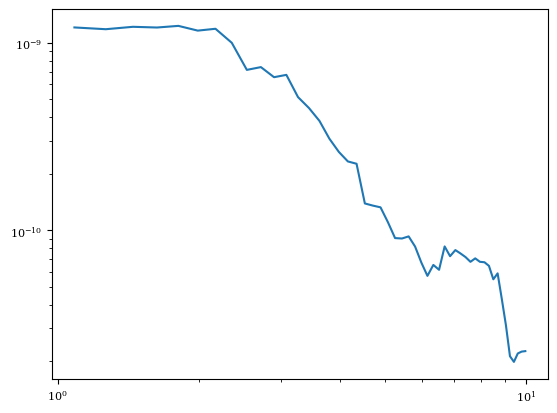

In [96]:
f = f_dict['TI3A']
Pxx = Pxx_dict['TI3A']

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(f,Pxx)
ax.set_xscale('log')
ax.set_yscale('log')

In [97]:
results

{'TI4A': (array([-19.71940906,   1.12084954,   0.14732275]),
  array([[0.01875888, 0.08898424, 0.01116386],
         [0.08898424, 0.52773801, 0.06257169],
         [0.01116386, 0.06257169, 0.00753365]]),
  {'fvec': array([ 1.81072840e-10,  1.74251594e-10,  3.00168197e-11, -5.61156999e-11,
          -1.79271556e-10, -1.68356569e-10, -3.28093787e-10, -1.63354354e-10,
          -7.26541160e-11, -3.39992878e-11,  1.74116747e-10,  1.09887040e-10,
           1.14833314e-10,  1.07586175e-10,  5.97262566e-11,  3.51588223e-11,
          -2.24065965e-12, -2.42357088e-11, -4.65672164e-11, -5.00030514e-11,
           8.09031848e-12,  8.78768907e-11,  1.09289609e-10,  1.05604554e-10,
           8.35726989e-11,  8.00036512e-11,  5.97271173e-11,  4.71834950e-11,
           3.88938243e-11,  3.34909456e-11,  1.61816356e-11,  2.10295345e-11,
           2.11391698e-11,  1.10985182e-11,  7.19572209e-12, -3.51063527e-12,
          -2.73985657e-11, -3.22970384e-11, -3.80328111e-11, -3.99917301e-11,
        

In [98]:
cont = chi2.ppf(0.95,2)

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning:

invalid value encountered in intersects

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/set_operations.py:133: RuntimeWarning:

invalid value encountered in intersection

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning:

invalid value encountered in buffer

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning:

invalid value encountered in buffer



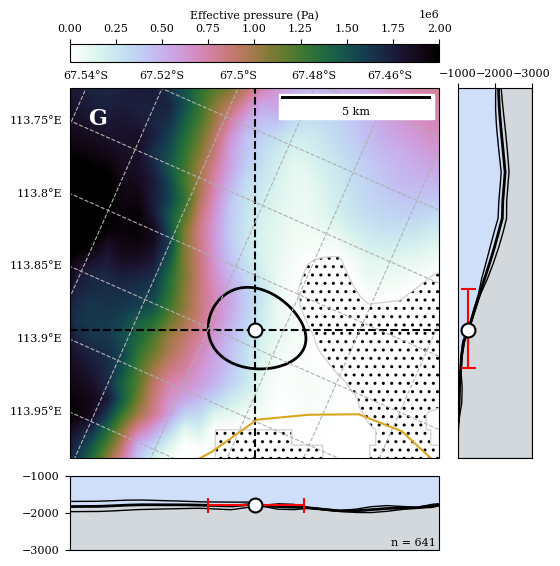

In [99]:
#interpolate hydrology onto bedgrid
gamma = gamma_cov.gamma.to_numpy()

x_ind, y_ind = np.unravel_index(np.argmin(gamma),gamma.shape)
x_loc = xlin[x_ind]
y_loc = ylin[y_ind]

x_ind_err = np.where(gamma[:,y_ind] <= cont)[0]
y_ind_err = np.where(gamma[x_ind,:] <= cont)[0]

#x_ind_err, y_ind_err = np.where(gamma_cov <= cont)

fig = plt.figure()

ne_ax = fig.add_subplot(111,projection = ccrs.SouthPolarStereo())
gl = ne_ax.gridlines(crs=wgs84, draw_labels = {'top':'y','left':'x'}, linestyle = '--',x_inline=False,y_inline=False,rotate_labels=False)

ne_ax.add_geometries(up_xy, crs=ccrs.epsg(3031), facecolor="none", edgecolor="goldenrod", linewidth=1.5,zorder=20)
#ne_ax.add_geometries(dn_ll, crs=wgs84, facecolor="none", edgecolor="palegoldenrod", linewidth=1.5, zorder=10)
#ne_ax.add_geometries(isl_ll, crs=wgs84, facecolor="none", edgecolor="white", linewidth=1.5, zorder=10)

ep = bed_grid.effective_pressure.values


pc_ep = ne_ax.pcolormesh(xlin,ylin,ep.T,cmap='cubehelix_r',vmin=0,vmax=2e6,shading='gouraud',transform=stereo)
ep_c = ne_ax.contour(xlin,ylin,ep.T,levels=[0],colors=['lightgrey'],linewidths=[1],transform=stereo)

hatches = ne_ax.contourf(xlin,ylin,ep.T,levels=[-2.5e5,0], colors='none',hatches=['..'],transform=stereo)
#hatches.set_edgecolor('lightgrey')

ne_ax.scatter(x_loc,y_loc,marker='o',s=100,zorder=5,color='white',edgecolors='black',linewidths=1.5,transform=stereo)
ne_ax.set_aspect('equal')

ne_ax.contour(xlin,ylin,gamma.T,levels=[cont],colors=['black'],linewidths=[2],transform=stereo)
#ne_ax.contour(xlin,ylin,gamma_simple.T,levels=[cont],colors=['black'],linewidths=[1.5],linestyles=['--'],transform=stereo)


for i, sta_name in enumerate(sta_lst):

    sta_x = sta_xy[i,0]
    sta_y = sta_xy[i,1]

    if (((sta_x <= xlin[-1]) & (sta_x >= xlin[0])) & ((sta_y <= ylin[-1]) & (sta_y >= ylin[0]))):
        ne_ax.scatter(sta_x,sta_y,marker='^',color='red',s=50,transform=stereo)
        ne_ax.annotate(sta_name,(sta_x,sta_y),c='white',weight='bold',zorder=5,size=10,transform=stereo)

x_proj = ccrs.SouthPolarStereo().transform_points(ccrs.epsg(3031),xlin,np.full_like(xlin,y_loc))[:,0]
y_proj = ccrs.SouthPolarStereo().transform_points(ccrs.epsg(3031),ylin,np.full_like(ylin,x_loc))[:,0]

ne_ax.set_xlim((x_proj[0],x_proj[-1]))
ne_ax.set_ylim((y_proj[0],y_proj[-1]))


ez_ax = ne_ax.inset_axes(bounds = [0.0,-0.25,1,0.2],transform=ne_ax.transAxes,sharex=ne_ax)

bed_x = bed_grid.isel(x=x_ind).bed_topography.values
bed_dx = bed_grid.isel(x=x_ind).bed_uncertainty.values

ez_ax.fill_between(x_proj,-3000,bed_x,color='slategrey',alpha=0.3)
ez_ax.fill_between(x_proj,bed_x,-1000,color='cornflowerblue',alpha=0.3)

ez_ax.plot(x_proj,bed_x,lw=2,color='black')
ez_ax.plot(x_proj,bed_x + bed_dx,lw=1,color='black')
ez_ax.plot(x_proj,bed_x - bed_dx,lw=1,color='black')
ez_ax.set_ylim(-3000,-1000)

nz_ax = ne_ax.inset_axes(bounds = [1.05,0,0.2,1],transform=ne_ax.transAxes,sharey=ne_ax)

bed_y = bed_grid.isel(y=y_ind).bed_topography.values
bed_dy = bed_grid.isel(y=y_ind).bed_uncertainty.values

nz_ax.fill_betweenx(y_proj,bed_y,-3000,color='slategrey',alpha=0.3)
nz_ax.fill_betweenx(y_proj,-1000,bed_y,color='cornflowerblue',alpha=0.3)

nz_ax.plot(bed_y,y_proj,lw=2,color='black')
nz_ax.plot(bed_y + bed_dy,y_proj,lw=1,color='black')
nz_ax.plot(bed_y - bed_dy,y_proj,lw=1,color='black')
nz_ax.set_xlim(-1000,-3000)

ne_ax.hlines(ylin[y_ind],xmin=xlin[0],xmax=xlin[-1],color='black',ls='--',transform=stereo)
ne_ax.vlines(xlin[x_ind],ymin=ylin[0],ymax=ylin[-1],color='black',ls='--',transform=stereo)

ez_ax.scatter(x_proj[x_ind],bed_x[x_ind],marker='o',s=100,zorder=5,color='white',edgecolors='black',linewidths=1.5)
nz_ax.scatter(bed_y[y_ind],y_proj[y_ind],marker='o',s=100,zorder=5,color='white',edgecolors='black',linewidths=1.5)


x_range = (x_proj[np.min(x_ind_err)],x_proj[np.max(x_ind_err)])
y_range = (y_proj[np.min(y_ind_err)],y_proj[np.max(y_ind_err)])

ez_ax.hlines(bed_x[x_ind],xmin=x_range[0],xmax=x_range[1],color='red')
ez_ax.vlines(x_range,ymin=bed_x[x_ind]-200,ymax=bed_x[x_ind]+200,color='red')
#ez_ax.plot(x_proj[x_ind_err],bed_x[x_ind_err],color='red')

nz_ax.vlines(bed_y[y_ind],ymin=y_range[0],ymax=y_range[1],color='red')
nz_ax.hlines(y_range,xmin=bed_y[y_ind]-200,xmax=bed_y[y_ind]+200,color='red')
#nz_ax.plot(bed_y[y_ind_err],y_proj[y_ind_err],color='red')

ez_ax.set_xticks([])
nz_ax.set_yticks([])

nz_ax.xaxis.set_ticks_position('top')

cb_ax = ne_ax.inset_axes(bounds = [0,1.07,1,0.05],transform=ne_ax.transAxes)
clb = fig.colorbar(pc_ep, cax = cb_ax,orientation='horizontal')
clb.set_label('Effective pressure (Pa)')
cb_ax.xaxis.set_ticks_position('top')
cb_ax.xaxis.set_label_position('top')


scalebar = ScaleBar(0.001, "km", length_fraction=0.25,border_pad=0.5,fixed_value=5)
ne_ax.add_artist(scalebar)

label = cluster_labels['Label'][cluster_num]
ne_ax.annotate(label,(0.05,0.9),xycoords='axes fraction',c='white',fontsize=16,weight='bold')

N_group = groups[int(cluster_num)].N

ez_ax.annotate('n = ' + str(N_group),(0.99,0.03),xycoords='axes fraction',ha='right',va='bottom')

plt.show()

In [100]:
cmap = plt.colormaps.get_cmap('Greens')

def cb_map(val,cb_min,cb_max):
    mapped = (val - cb_min) / (cb_max - cb_min)
    return mapped

/var/folders/z4/gw28hj796zjdxt4nltp_h5g1m6cl00/T/ipykernel_98348/2207695845.py:14: FutureWarning:

This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning:

'+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning:

'+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6

/Users/jmagyar/Documents/icequakecode

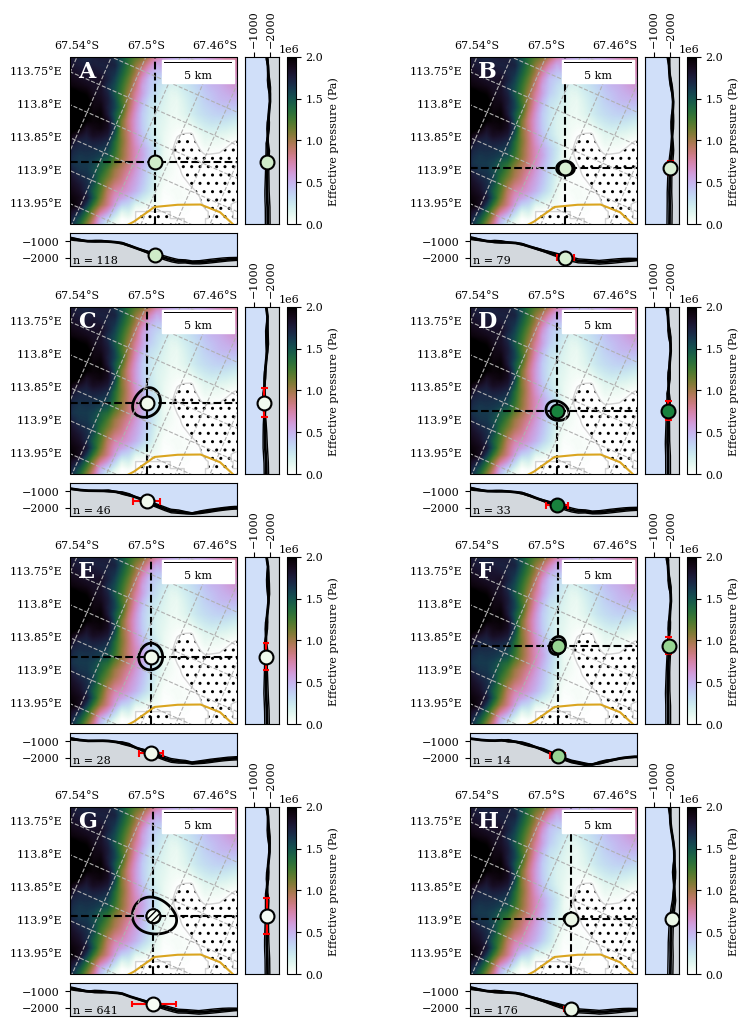

In [101]:
#loop over all the groups and combine into a large master figure...
#master_fig = plt.figure(figsize=(8.5,13))#,layout='constrained')
master_fig = plt.figure(figsize=(8,10))#,layout='constrained')

gs = master_fig.add_gridspec(nrows=8,ncols=4,height_ratios=4*[1,0.15],width_ratios=2*[1,0.15])
subfigs = [master_fig.add_subfigure(gs[(i//2)*2,(i%2)*2]) for i in range(8)]
#subfigs = master_fig.subfigures(nrows=4,ncols=2,hspace=0.1,wspace=0.1).flatten()

for i, cluster_num in enumerate([31,43,34,44,33,32,39,54]):
    label = cluster_labels['Label'][cluster_num]
    tide_mod = cluster_labels['KL_height'][cluster_num]
    color = cmap(cb_map(tide_mod,0,0.75)) #pick the colour based on the tidal skewness.

    
    p_picks = pd.read_csv(os.path.join(path,'stacked_waveforms','manual_picks_' + str(cluster_num) + '.csv'),index_col=0)
    p_picks['mu'] = p_picks['P1'] + (p_picks['P2'] - p_picks['P1'])/2
    p_picks['sigma'] = (p_picks['P2'] - p_picks['P1'])/4

    gamma_xr = BedScan(inv,p_picks,bed_grid,V=3870,sigma_V=50,Delta=10000,bed_error=True,no_model_error=False)

    #save the xarray dataset
    gamma_xr.to_netcdf(os.path.join(path,'misfit','misfit_surface_'+str(cluster_num)+'.nc'))
    #gamma_simple = BedScan(inv,p_picks,bed_grid,V=3870,sigma_V=50,Delta=10000,bed_error=True,no_model_error=True)

    gamma = gamma_xr.gamma.to_numpy()
    
    x_ind, y_ind = np.unravel_index(np.argmin(gamma),gamma.shape)
    x_loc = xlin[x_ind]
    y_loc = ylin[y_ind]

    x_ind_err = np.where(gamma[:,y_ind] <= cont)[0]
    y_ind_err = np.where(gamma[x_ind,:] <= cont)[0]


    fig = subfigs[i]

    ne_ax = fig.add_subplot(111,projection = ccrs.SouthPolarStereo())
    gl = ne_ax.gridlines(crs=wgs84, draw_labels = {'top':'y','left':'x'}, linestyle = '--',x_inline=False,y_inline=False,rotate_labels=False)

    ne_ax.add_geometries(up_xy, crs=ccrs.epsg(3031), facecolor="none", edgecolor="goldenrod", linewidth=1.5,zorder=20)
    #ne_ax.add_geometries(dn_ll, crs=wgs84, facecolor="none", edgecolor="palegoldenrod", linewidth=1.5, zorder=10)
    #ne_ax.add_geometries(isl_ll, crs=wgs84, facecolor="none", edgecolor="white", linewidth=1.5, zorder=10)

    ep = bed_grid.effective_pressure.values


    pc_ep = ne_ax.pcolormesh(xlin,ylin,ep.T,cmap='cubehelix_r',vmin=0,vmax=2e6,shading='gouraud',transform=stereo,rasterized=True)
    ep_c = ne_ax.contour(xlin,ylin,ep.T,levels=[0],colors=['lightgrey'],linewidths=[1],transform=stereo)

    hatches = ne_ax.contourf(xlin,ylin,ep.T,levels=[-2.5e5,0], colors='none',hatches=['..'],transform=stereo)
    #hatches.set_edgecolor('lightgrey')

    ne_ax.scatter(x_loc,y_loc,marker='o',s=100,zorder=5,color=color,edgecolors='black',linewidths=1.5,transform=stereo)

    if label == 'G':
        ne_ax.scatter(x_loc,y_loc,marker='o',s=100,zorder=5,color=color,edgecolors='black',linewidths=1.5,transform=stereo,hatch='/////')

    ne_ax.set_aspect('equal')

    ne_ax.contour(xlin,ylin,gamma.T,levels=[cont],colors=['black'],linewidths=[2],transform=stereo)
    #ne_ax.contour(xlin,ylin,gamma_simple.T,levels=[cont],colors=['black'],linewidths=[1.5],linestyles=['--'],transform=stereo)


    for i, sta_name in enumerate(sta_lst):

        sta_x = sta_xy[i,0]
        sta_y = sta_xy[i,1]

        if (((sta_x <= xlin[-1]) & (sta_x >= xlin[0])) & ((sta_y <= ylin[-1]) & (sta_y >= ylin[0]))):
            ne_ax.scatter(sta_x,sta_y,marker='^',color='red',s=50,transform=stereo)
            ne_ax.annotate(sta_name,(sta_x,sta_y),c='white',weight='bold',zorder=5,size=10,transform=stereo)

    x_proj = ccrs.SouthPolarStereo().transform_points(ccrs.epsg(3031),xlin,np.full_like(xlin,y_loc))[:,0]
    y_proj = ccrs.SouthPolarStereo().transform_points(ccrs.epsg(3031),ylin,np.full_like(ylin,x_loc))[:,0]

    ne_ax.set_xlim((x_proj[0],x_proj[-1]))
    ne_ax.set_ylim((y_proj[0],y_proj[-1]))


    ez_ax = ne_ax.inset_axes(bounds = [0.0,-0.25,1,0.2],transform=ne_ax.transAxes,sharex=ne_ax)

    bed_x = bed_grid.isel(y=y_ind).bed_topography.values
    bed_dx = bed_grid.isel(y=y_ind).bed_uncertainty.values

    ez_ax.fill_between(x_proj,-2500,bed_x,color='slategrey',alpha=0.3)
    ez_ax.fill_between(x_proj,bed_x,-500,color='cornflowerblue',alpha=0.3)

    ez_ax.plot(x_proj,bed_x,lw=2,color='black')
    ez_ax.plot(x_proj,bed_x + bed_dx,lw=1,color='black')
    ez_ax.plot(x_proj,bed_x - bed_dx,lw=1,color='black')
    ez_ax.set_ylim(-2500,-500)

    nz_ax = ne_ax.inset_axes(bounds = [1.05,0,0.2,1],transform=ne_ax.transAxes,sharey=ne_ax)

    bed_y = bed_grid.isel(x=x_ind).bed_topography.values
    bed_dy = bed_grid.isel(x=x_ind).bed_uncertainty.values

    nz_ax.fill_betweenx(y_proj,bed_y,-2500,color='slategrey',alpha=0.3)
    nz_ax.fill_betweenx(y_proj,-500,bed_y,color='cornflowerblue',alpha=0.3)

    nz_ax.plot(bed_y,y_proj,lw=2,color='black')
    nz_ax.plot(bed_y + bed_dy,y_proj,lw=1,color='black')
    nz_ax.plot(bed_y - bed_dy,y_proj,lw=1,color='black')
    nz_ax.set_xlim(-500,-2500)

    ne_ax.hlines(ylin[y_ind],xmin=xlin[0],xmax=xlin[-1],color='black',ls='--',transform=stereo)
    ne_ax.vlines(xlin[x_ind],ymin=ylin[0],ymax=ylin[-1],color='black',ls='--',transform=stereo)

    ez_ax.scatter(x_proj[x_ind],bed_x[x_ind],marker='o',s=100,zorder=5,color=color,edgecolors='black',linewidths=1.5)
    nz_ax.scatter(bed_y[y_ind],y_proj[y_ind],marker='o',s=100,zorder=5,color=color,edgecolors='black',linewidths=1.5)

    x_range = (x_proj[np.min(x_ind_err)],x_proj[np.max(x_ind_err)])
    y_range = (y_proj[np.min(y_ind_err)],y_proj[np.max(y_ind_err)])

    ez_ax.hlines(bed_x[x_ind],xmin=x_range[0],xmax=x_range[1],color='red')
    ez_ax.vlines(x_range,ymin=bed_x[x_ind]-200,ymax=bed_x[x_ind]+200,color='red')

    nz_ax.vlines(bed_y[y_ind],ymin=y_range[0],ymax=y_range[1],color='red')
    nz_ax.hlines(y_range,xmin=bed_y[y_ind]-200,xmax=bed_y[y_ind]+200,color='red')

    ez_ax.set_xticks([])
    nz_ax.set_yticks([])

    nz_ax.tick_params(axis='x', labelrotation=90)


    nz_ax.xaxis.set_ticks_position('top')

    cb_ax = ne_ax.inset_axes(bounds = [1.3,0,0.05,1],transform=ne_ax.transAxes)
    clb = fig.colorbar(pc_ep, cax = cb_ax)
    clb.set_label('Effective pressure (Pa)')
    cb_ax.yaxis.get_offset_text().set_position((1.5,1))

    #cb_ax.xaxis.set_ticks_position('top')
    #cb_ax.xaxis.set_label_position('top')


    scalebar = ScaleBar(0.001, "km", length_fraction=0.25,border_pad=0.25,fixed_value=5)
    ne_ax.add_artist(scalebar)
    ne_ax.annotate(label,(0.05,0.88),xycoords='axes fraction',c='white',fontsize=16,weight='bold')
    
    N_group = groups[int(cluster_num)].N
    ez_ax.annotate('n = ' + str(N_group),(0.02,0.03),xycoords='axes fraction',ha='left',va='bottom')


master_fig.savefig(os.path.join(cloud_path,'FigS3_travel_time_inversion.pdf'),bbox_inches='tight',dpi=400)

In [102]:
def cmap_bedmachine():
  colors = [
    (17/256, 29/256, 57/256), # Dark blue
    (59/256, 89/256, 130/256), # Navy blue
    (102/256, 172/256, 222/256), # Baby blue
    (255/256, 255/256, 255/256), # White
    (58/256, 97/256, 39/256), # Dark green
    (93/256, 156/256, 63/256), # Green
    (195/256, 180/256, 79/256), # Yellow
    (107/256, 82/256, 0), # Brown
    (52/256 ,37/256, 0) # Dark brown
  ]
  values = [-3000, -1000, -500, 0, 1, 500, 1000, 1500, 3000]
  norm = plt.Normalize(min(values), max(values))
  cmapping = list(zip(norm(values), colors))
  custom_cmap = LinearSegmentedColormap.from_list(name = 'BedMachine', colors = cmapping)
  return custom_cmap

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning:

invalid value encountered in intersects

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/set_operations.py:133: RuntimeWarning:

invalid value encountered in intersection

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning:

invalid value encountered in buffer

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning:

invalid value encountered in buffer

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning:

invalid value encountered in buffer

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning:

invalid value encountered in buffer

/Users/jmagy

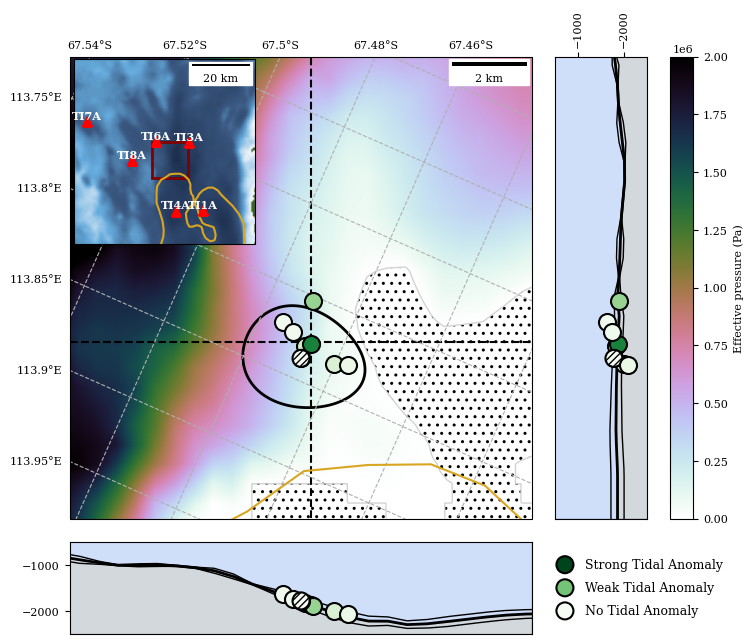

In [103]:
fig = plt.figure(figsize=(6,6))

ne_ax = fig.add_subplot(111,projection = ccrs.SouthPolarStereo())
ez_ax = ne_ax.inset_axes(bounds = [0.0,-0.25,1,0.2],transform=ne_ax.transAxes,sharex=ne_ax)
nz_ax = ne_ax.inset_axes(bounds = [1.05,0,0.2,1],transform=ne_ax.transAxes,sharey=ne_ax)
dot_ax = ne_ax.inset_axes(bounds = [1.05,-0.25,0.2,0.2],transform=ne_ax.transAxes)

gl = ne_ax.gridlines(crs=wgs84, draw_labels = {'top':'y','left':'x'}, linestyle = '--',x_inline=False,y_inline=False,rotate_labels=False)

ne_ax.add_geometries(up_xy, crs=ccrs.epsg(3031), facecolor="none", edgecolor="goldenrod", linewidth=1.5,zorder=20)
#ne_ax.add_geometries(dn_ll, crs=wgs84, facecolor="none", edgecolor="palegoldenrod", linewidth=1.5, zorder=10)
#ne_ax.add_geometries(isl_ll, crs=wgs84, facecolor="none", edgecolor="white", linewidth=1.5, zorder=10)

ep = bed_grid.effective_pressure.values


pc_ep = ne_ax.pcolormesh(xlin,ylin,ep.T,cmap='cubehelix_r',vmin=0,vmax=2e6,shading='gouraud',transform=stereo,rasterized=True)
ep_c = ne_ax.contour(xlin,ylin,ep.T,levels=[0],colors=['lightgrey'],linewidths=[1],transform=stereo)

hatches = ne_ax.contourf(xlin,ylin,ep.T,levels=[-2.5e5,0], colors='none',hatches=['..'],transform=stereo)
#hatches.set_edgecolor('lightgrey')

ne_ax.set_aspect('equal')

x_tot = 0.0
y_tot = 0.0

for i, cluster_num in enumerate([31,43,34,44,33,32,39,54]):
    label = cluster_labels['Label'][cluster_num]
    kl_height = cluster_labels['KL_height'][cluster_num]

    gamma_xr = xr.load_dataset(os.path.join(path,'misfit','misfit_surface_'+str(cluster_num)+'.nc'))

    xlin = gamma_xr.x.to_numpy()
    ylin = gamma_xr.y.to_numpy()
    gamma = gamma_xr.gamma.to_numpy()

    x_ind, y_ind = np.unravel_index(np.argmin(gamma),gamma.shape)
    x_loc = xlin[x_ind]
    y_loc = ylin[y_ind]

    z_loc = bed_grid.bed_topography.isel(x=x_ind,y=y_ind)

    x_tot += x_loc
    y_tot += y_loc

    color = cmap(cb_map(kl_height,0,0.75)) #pick the colour based on the tidal skewness.

    ne_ax.scatter(x_loc,y_loc,marker='o',s=150,zorder=5,color=color,edgecolors='black',linewidths=1.5,transform=stereo)

    if label == 'G':
        ne_ax.contour(xlin,ylin,gamma.T,levels=[cont],colors=['black'],linewidths=[2],transform=stereo)
        ne_ax.scatter(x_loc,y_loc,marker='o',s=150,zorder=5,color=color,edgecolors='black',linewidths=1.5,transform=stereo,hatch='/////')

    x_proj = ccrs.SouthPolarStereo().transform_points(ccrs.epsg(3031),xlin,np.full_like(xlin,y_loc))[:,0]
    y_proj = ccrs.SouthPolarStereo().transform_points(ccrs.epsg(3031),ylin,np.full_like(ylin,x_loc))[:,0]

    ez_ax.scatter(x_proj[x_ind],z_loc,marker='o',s=150,zorder=5,color=color,edgecolors='black',linewidths=1.5)
    nz_ax.scatter(z_loc,y_proj[y_ind],marker='o',s=150,zorder=5,color=color,edgecolors='black',linewidths=1.5)

    if label == 'G':
        ez_ax.scatter(x_proj[x_ind],z_loc,marker='o',s=150,zorder=5,color=color,edgecolors='black',linewidths=1.5,hatch='/////')
        nz_ax.scatter(z_loc,y_proj[y_ind],marker='o',s=150,zorder=5,color=color,edgecolors='black',linewidths=1.5,hatch='/////')


mean_x = x_tot / 8
mean_y = y_tot / 8

for i, sta_name in enumerate(sta_lst):

    sta_x = sta_xy[i,0]
    sta_y = sta_xy[i,1]

    if (((sta_x <= xlin[-1]) & (sta_x >= xlin[0])) & ((sta_y <= ylin[-1]) & (sta_y >= ylin[0]))):
        ne_ax.scatter(sta_x,sta_y,marker='^',color='red',s=50,transform=stereo)
        ne_ax.annotate(sta_name,(sta_x,sta_y),c='white',weight='bold',zorder=5,size=10,transform=stereo,va='bottom')



ne_ax.set_xlim((x_proj[0],x_proj[-1]))
ne_ax.set_ylim((y_proj[0],y_proj[-1]))

bed_x = bed_grid.interp(y=mean_y).bed_topography.values
bed_dx = bed_grid.interp(y=mean_y).bed_uncertainty.values

ez_ax.fill_between(x_proj,-2500,bed_x,color='slategrey',alpha=0.3)
ez_ax.fill_between(x_proj,bed_x,-500,color='cornflowerblue',alpha=0.3)

ez_ax.plot(x_proj,bed_x,lw=2,color='black')
ez_ax.plot(x_proj,bed_x + bed_dx,lw=1,color='black')
ez_ax.plot(x_proj,bed_x - bed_dx,lw=1,color='black')
ez_ax.set_yticks([-1000,-2000])
ez_ax.set_ylim(-2500,-500)


bed_y = bed_grid.interp(x=mean_x).bed_topography.values
bed_dy = bed_grid.interp(x=mean_x).bed_uncertainty.values

nz_ax.fill_betweenx(y_proj,bed_y,-2500,color='slategrey',alpha=0.3)
nz_ax.fill_betweenx(y_proj,-500,bed_y,color='cornflowerblue',alpha=0.3)

nz_ax.plot(bed_y,y_proj,lw=2,color='black')
nz_ax.plot(bed_y + bed_dy,y_proj,lw=1,color='black')
nz_ax.plot(bed_y - bed_dy,y_proj,lw=1,color='black')
nz_ax.set_xticks([-1000,-2000])
nz_ax.set_xlim(-500,-2500)

ne_ax.hlines(mean_y,xmin=xlin[0],xmax=xlin[-1],color='black',ls='--',transform=stereo)
ne_ax.vlines(mean_x,ymin=ylin[0],ymax=ylin[-1],color='black',ls='--',transform=stereo)



# x_range = (x_proj[np.min(x_ind_err)],x_proj[np.max(x_ind_err)])
# y_range = (y_proj[np.min(y_ind_err)],y_proj[np.max(y_ind_err)])

# ez_ax.hlines(bed_x[x_ind],xmin=x_range[0],xmax=x_range[1],color='red')
# ez_ax.vlines(x_range,ymin=bed_x[x_ind]-200,ymax=bed_x[x_ind]+200,color='red')

# nz_ax.vlines(bed_y[y_ind],ymin=y_range[0],ymax=y_range[1],color='red')
# nz_ax.hlines(y_range,xmin=bed_y[y_ind]-200,xmax=bed_y[y_ind]+200,color='red')

ez_ax.set_xticks([])
nz_ax.set_yticks([])

nz_ax.tick_params(axis='x', labelrotation=90)


nz_ax.xaxis.set_ticks_position('top')

cb_ax = ne_ax.inset_axes(bounds = [1.3,0,0.05,1],transform=ne_ax.transAxes)
clb = fig.colorbar(pc_ep, cax = cb_ax)
clb.set_label('Effective pressure (Pa)')
#cb_ax.yaxis.get_offset_text().set_position((1.5,1))

#cb_ax.xaxis.set_ticks_position('top')
#cb_ax.xaxis.set_label_position('top')


scalebar = ScaleBar(0.001, "km", length_fraction=0.25,border_pad=0.25,fixed_value=2)
ne_ax.add_artist(scalebar)

dot_c = cmap(cb_map(np.array([0,0.5,1]),0,1))
dot_ax.scatter([0,0,0],[1,2,3],c=dot_c,marker='o',s=150,zorder=5,edgecolors='black',linewidths=1.5)

dot_ax.set_ylim(0,4)
dot_ax.set_xlim(-0.5,4)
dot_ax.set_axis_off()

dot_ax.annotate('Strong Tidal Anomaly',xy=(1,3),ha='left',va='center',fontsize=9)
dot_ax.annotate('Weak Tidal Anomaly',xy=(1,2),ha='left',va='center',fontsize=9)
dot_ax.annotate('No Tidal Anomaly',xy=(1,1),ha='left',va='center',fontsize=9)

inset_ax = ne_ax.inset_axes(bounds = [0.005, 1-0.4-0.005, 0.4, 0.4], transform = ne_ax.transAxes, projection = ccrs.SouthPolarStereo(),zorder=50)
inset_ax.set_extent([113.2, 114.3, -67.7, -67.3],crs=wgs84)


inset_grid = xr.Dataset(coords=dict(x=("x", np.mgrid[2.2e6:2.3e6:500]),y=("y", np.mgrid[-1.1e6:-0.95e6:500])))
bedmap_interp = bedmap3.interp_like(inset_grid)
inset_grid = inset_grid.assign(dict(bed_topography = bedmap_interp.bed_topography))

inset_ax.pcolormesh(inset_grid.x,inset_grid.y,inset_grid.bed_topography,shading='gouraud',rasterized=True, transform=stereo,cmap = cmap_bedmachine(),vmin=-3000,vmax=3000)

_, inset_indicator = inset_ax.indicate_inset_zoom(ne_ax, edgecolor = 'maroon',alpha=1,linewidth=2) # indicate on main axes the inset axes

for connector in inset_indicator:
    connector.set_visible(False)


inset_ax.add_geometries(up_xy, crs=ccrs.epsg(3031), facecolor="none", edgecolor="goldenrod", linewidth=1.5,zorder=20)
inset_ax.add_geometries(dn_ll, crs=ccrs.epsg(3031), facecolor="none", edgecolor="palegoldenrod", linewidth=1.5, zorder=20)
inset_ax.add_geometries(isl_ll, crs=ccrs.epsg(3031), facecolor="none", edgecolor="white", linewidth=1.5, zorder=20)


for i, sta_name in enumerate(sta_lst):

    sta_x = sta_xy[i,0]
    sta_y = sta_xy[i,1]

    inset_ax.scatter(sta_x,sta_y,marker='^',color='red',s=50,transform=stereo,zorder=30)
    inset_ax.annotate(sta_name,(sta_x,sta_y),c='white',weight='bold',zorder=30,size=8,transform=stereo,ha='center',va='bottom')


scalebar = ScaleBar(0.001, "km", length_fraction=0.25,border_pad=0.25,fixed_value=20)
inset_ax.add_artist(scalebar)

fig.savefig(os.path.join(cloud_path,'Fig3_cluster_tide_locations.pdf'),bbox_inches='tight',dpi=400)

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning:

invalid value encountered in intersects

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/set_operations.py:133: RuntimeWarning:

invalid value encountered in intersection

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning:

invalid value encountered in buffer

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning:

invalid value encountered in buffer



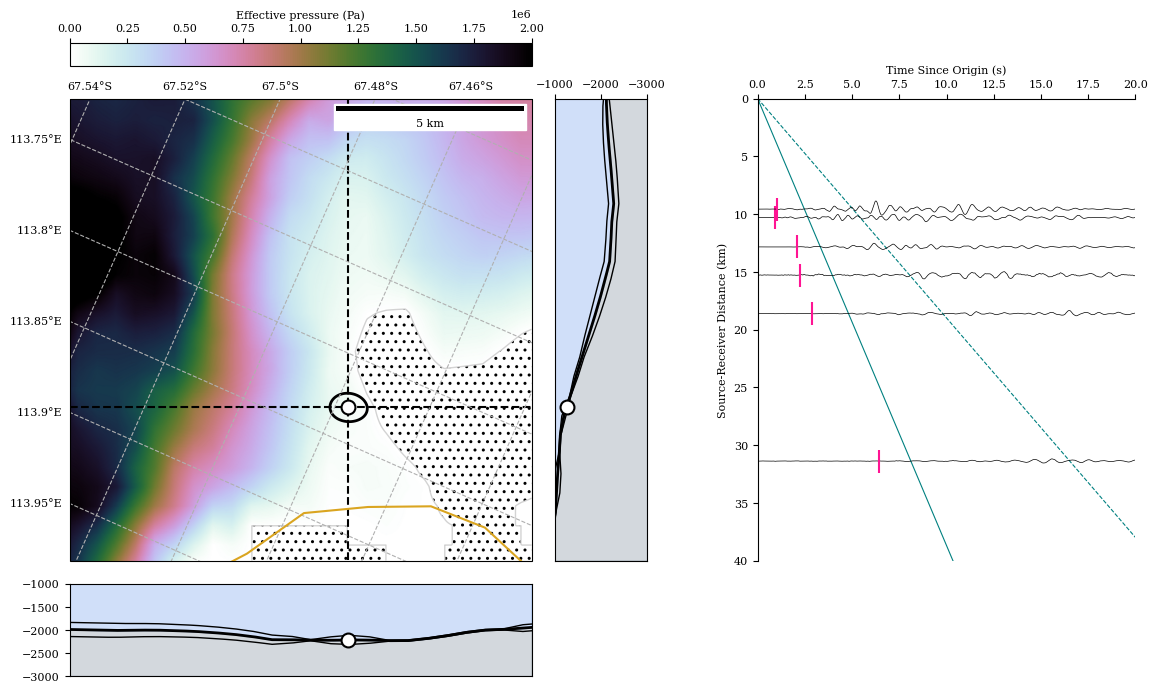

In [104]:
#interpolate hydrology onto bedgrid
master_fig = plt.figure(figsize=(13,6))

fig, rollout_fig = master_fig.subfigures(ncols=2,width_ratios=(1,0.6))

ne_ax = fig.add_subplot(111,projection = ccrs.SouthPolarStereo())
gl = ne_ax.gridlines(crs=wgs84, draw_labels = {'top':'y','left':'x'}, linestyle = '--',x_inline=False,y_inline=False,rotate_labels=False)

ne_ax.add_geometries(up_xy, crs=ccrs.epsg(3031), facecolor="none", edgecolor="goldenrod", linewidth=1.5,zorder=20)
#ne_ax.add_geometries(dn_ll, crs=wgs84, facecolor="none", edgecolor="palegoldenrod", linewidth=1.5, zorder=10)
#ne_ax.add_geometries(isl_ll, crs=wgs84, facecolor="none", edgecolor="white", linewidth=1.5, zorder=10)

ep = bed_grid.effective_pressure.values


pc_ep = ne_ax.pcolormesh(xlin,ylin,ep.T,cmap='cubehelix_r',vmin=0,vmax=2e6,shading='gouraud',transform=stereo)
ep_c = ne_ax.contour(xlin,ylin,ep.T,levels=[0],colors=['lightgrey'],linewidths=[1],transform=stereo)

hatches = ne_ax.contourf(xlin,ylin,ep.T,levels=[-2.5e5,0], colors='none',hatches=['..'],transform=stereo)
#hatches.set_edgecolor('lightgrey')

ne_ax.scatter(x_loc,y_loc,marker='o',s=100,zorder=5,color='white',edgecolors='black',linewidths=1.5,transform=stereo)
ne_ax.set_aspect('equal')

ne_ax.contour(xlin,ylin,gamma.T,levels=[cont],colors=['black'],linewidths=[2],transform=stereo)
ne_ax.scatter(sta_xy[:,0],sta_xy[:,1],marker='v',color='red',s=50,transform=stereo)

x_proj = ccrs.SouthPolarStereo().transform_points(ccrs.epsg(3031),xlin,np.full_like(xlin,y_loc))[:,0]
y_proj = ccrs.SouthPolarStereo().transform_points(ccrs.epsg(3031),ylin,np.full_like(ylin,x_loc))[:,0]

ne_ax.set_xlim((x_proj[0],x_proj[-1]))
ne_ax.set_ylim((y_proj[0],y_proj[-1]))


ez_ax = ne_ax.inset_axes(bounds = [0.0,-0.25,1,0.2],transform=ne_ax.transAxes,sharex=ne_ax)

bed_x = bed_grid.isel(x=x_ind).bed_topography.values
bed_dx = bed_grid.isel(x=x_ind).bed_uncertainty.values

ez_ax.fill_between(x_proj,-3000,bed_x,color='slategrey',alpha=0.3)
ez_ax.fill_between(x_proj,bed_x,-1000,color='cornflowerblue',alpha=0.3)

ez_ax.plot(x_proj,bed_x,lw=2,color='black')
ez_ax.plot(x_proj,bed_x + bed_dx,lw=1,color='black')
ez_ax.plot(x_proj,bed_x - bed_dx,lw=1,color='black')
ez_ax.set_ylim(-3000,-1000)

nz_ax = ne_ax.inset_axes(bounds = [1.05,0,0.2,1],transform=ne_ax.transAxes,sharey=ne_ax)

bed_y = bed_grid.isel(y=y_ind).bed_topography.values
bed_dy = bed_grid.isel(y=y_ind).bed_uncertainty.values

nz_ax.fill_betweenx(y_proj,bed_y,-3000,color='slategrey',alpha=0.3)
nz_ax.fill_betweenx(y_proj,-1000,bed_y,color='cornflowerblue',alpha=0.3)

nz_ax.plot(bed_y,y_proj,lw=2,color='black')
nz_ax.plot(bed_y + bed_dy,y_proj,lw=1,color='black')
nz_ax.plot(bed_y - bed_dy,y_proj,lw=1,color='black')
nz_ax.set_xlim(-1000,-3000)

ne_ax.hlines(ylin[y_ind],xmin=xlin[0],xmax=xlin[-1],color='black',ls='--',transform=stereo)
ne_ax.vlines(xlin[x_ind],ymin=ylin[0],ymax=ylin[-1],color='black',ls='--',transform=stereo)

ez_ax.scatter(x_proj[x_ind],bed_x[x_ind],marker='o',s=100,zorder=5,color='white',edgecolors='black',linewidths=1.5)
nz_ax.scatter(bed_y[y_ind],y_proj[y_ind],marker='o',s=100,zorder=5,color='white',edgecolors='black',linewidths=1.5)

ez_ax.set_xticks([])
nz_ax.set_yticks([])

nz_ax.xaxis.set_ticks_position('top')

cb_ax = ne_ax.inset_axes(bounds = [0,1.07,1,0.05],transform=ne_ax.transAxes)
clb = fig.colorbar(pc_ep, cax = cb_ax,orientation='horizontal')
clb.set_label('Effective pressure (Pa)')
cb_ax.xaxis.set_ticks_position('top')
cb_ax.xaxis.set_label_position('top')


scalebar = ScaleBar(0.001, "km", length_fraction=0.25,border_pad=0.5,fixed_value=5)
ne_ax.add_artist(scalebar)

#bed_cb = ax.inset_axes(bounds = [0.37,0.01,0.025,0.35], transform = ax.transAxes)

#ne_ax.plot(x_fit,y_fit,marker='X',color='black')
#nz_ax.plot(z_fit,y_fit,marker='X',color='black')
#ez_ax.plot(x_fit,z_fit,marker='X',color='black')

# target = t_tilde[x_ind,y_ind,:] + t_ave[x_ind,y_ind] 
# fit = h_tilde[x_ind,y_ind,:] + t_ave[x_ind,y_ind]

# opt_dist = np.zeros(N)
# h_fit = np.zeros(N)

# for i, sta_code in enumerate(pick_sta):
#     opt_dist[i] = d.isel(x=x_ind,y=y_ind).variables[sta_code].values / 1000
#     h_fit[i] = h.isel(x=x_ind,y=y_ind).variables[sta_code].values

ax = rollout_fig.add_subplot(111)

#ax.hlines(opt_dist,xmin=0,xmax=20,ls='--',color='grey')

ax.invert_yaxis()
ax.set_ylim(top=0)

t = np.linspace(0,20)

rollout = V * t / 1000
rollout_S = 1900 * t / 1000

#t0 = np.mean(fit - h_fit) #all these values are actually the same (as they should be)

t0 = gamma_cov.attrs['t0']

ax.plot(t,rollout,color='teal',lw=0.8)
ax.plot(t,rollout_S,color='teal',ls='--',lw=0.8)

#ax.set_yticks(opt_dist)
#ax.set_yticklabels(sta_lst)
ax.set_xlim(0,20)
ax.set_ylim(40,0)

stream = read(os.path.join(w_path,'filtered_stacked_waveforms_cluster_' + str(cluster_num) + '.mseed'))

for i, sta_code in enumerate(gamma_cov.attrs['stations']):

    opt_dist = gamma_cov.attrs['D_'+sta_code] / 1000
    target = p_picks['mu'][sta_code]

    Z = stream.select(station=sta_code,component='Z')[0]

    ax.plot(Z.times()-t0,Z.data/50 + opt_dist,c='k',lw=0.5)
    ax.vlines(target - t0,ymin=opt_dist-1,ymax=opt_dist+1,color='deeppink')

ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

ax.set_xlabel('Time Since Origin (s)')
ax.set_ylabel('Source-Receiver Distance (km)')

plt.show()

### Confidence Intervals on $r_i$

In [105]:
#first want to take the misfit surface and convert it to a probability distribution (doesn't matter if its normalised yet...)

#then want to do some sort of interpolation into polar coordinates about each station individually, and marginalise over angles to get just as function of distance.

gamma_xr = xr.load_dataset(os.path.join(path,'misfit','misfit_surface_'+str(39)+'.nc'))


/var/folders/z4/gw28hj796zjdxt4nltp_h5g1m6cl00/T/ipykernel_98348/2207695845.py:14: FutureWarning:

This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning:

invalid value encountered in intersects

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/set_operations.py:133: RuntimeWarning:

invalid value encountered in intersection

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning:

invalid value encountered in buffer

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning:

invalid value encountered in intersects

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/set_operations.py:133: Ru

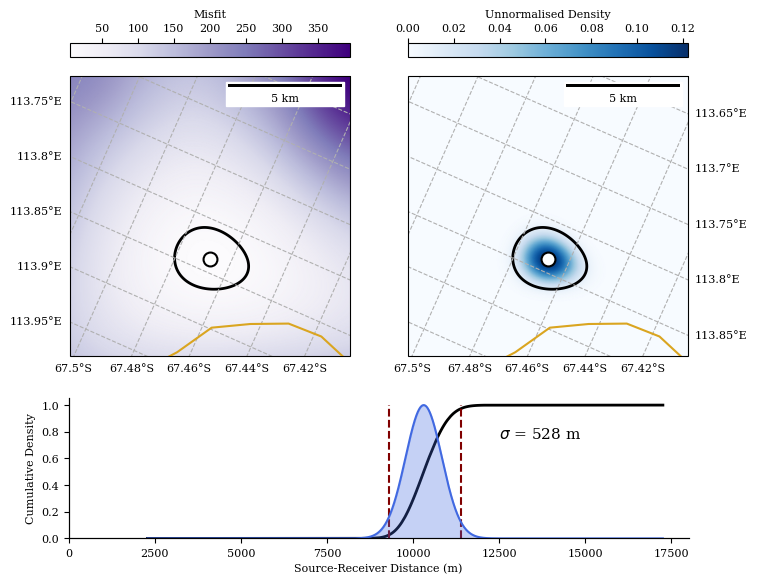

In [106]:
#plot these side-by-side for the supplementary material

fig = plt.figure(figsize=(8,6))

gs = fig.add_gridspec(ncols=2,nrows=2,height_ratios=[2,1])

chi2_surf = (gamma_xr.chi2 / gamma_xr.chi2.min()) * (7 - 2)
gamma = gamma_xr.gamma.to_numpy()

x_ind, y_ind = np.unravel_index(np.argmin(gamma),gamma.shape)
x_loc = xlin[x_ind]
y_loc = ylin[y_ind]

x_ind_err = np.where(gamma[:,y_ind] <= cont)[0]
y_ind_err = np.where(gamma[x_ind,:] <= cont)[0]


chi2_ax = fig.add_subplot(gs[0,0],projection = ccrs.SouthPolarStereo())
gl = chi2_ax.gridlines(crs=wgs84, draw_labels = {'bottom':'y','left':'x'}, linestyle = '--',x_inline=False,y_inline=False,rotate_labels=False)

chi2_ax.add_geometries(up_xy, crs=ccrs.epsg(3031), facecolor="none", edgecolor="goldenrod", linewidth=1.5,zorder=20)


pc_chi2 = chi2_ax.pcolormesh(xlin,ylin,chi2_surf.T,cmap='Purples',shading='gouraud',transform=stereo,rasterized=True)

chi2_ax.scatter(x_loc,y_loc,marker='o',s=100,zorder=5,color='white',edgecolors='black',linewidths=1.5,transform=stereo)
chi2_ax.set_aspect('equal')

chi2_ax.contour(xlin,ylin,gamma.T,levels=[cont],colors=['black'],linewidths=[2],transform=stereo)
#ne_ax.contour(xlin,ylin,gamma_simple.T,levels=[cont],colors=['black'],linewidths=[1.5],linestyles=['--'],transform=stereo)


for i, sta_name in enumerate(sta_lst):

    sta_x = sta_xy[i,0]
    sta_y = sta_xy[i,1]

    if (((sta_x <= xlin[-1]) & (sta_x >= xlin[0])) & ((sta_y <= ylin[-1]) & (sta_y >= ylin[0]))):
        chi2_ax.scatter(sta_x,sta_y,marker='^',color='red',s=50,transform=stereo)
        chi2_ax.annotate(sta_name,(sta_x,sta_y),c='white',weight='bold',zorder=5,size=10,transform=stereo)


cb_ax = chi2_ax.inset_axes(bounds = [0,1.07,1,0.05],transform=chi2_ax.transAxes)
clb = fig.colorbar(pc_chi2, cax = cb_ax,orientation='horizontal')
clb.set_label('Misfit')
cb_ax.xaxis.set_ticks_position('top')
cb_ax.xaxis.set_label_position('top')


scalebar = ScaleBar(0.001, "km", length_fraction=0.25,border_pad=0.5,fixed_value=5)
chi2_ax.add_artist(scalebar)


pdf = chi2.pdf(chi2_surf,5)


pdf_ax = fig.add_subplot(gs[0,1],projection = ccrs.SouthPolarStereo())
gl = pdf_ax.gridlines(crs=wgs84, draw_labels = {'bottom':'y','right':'x'}, linestyle = '--',x_inline=False,y_inline=False,rotate_labels=False)

pdf_ax.add_geometries(up_xy, crs=ccrs.epsg(3031), facecolor="none", edgecolor="goldenrod", linewidth=1.5,zorder=20)


pc_pdf = pdf_ax.pcolormesh(xlin,ylin,pdf.T,cmap='Blues',shading='gouraud',transform=stereo,rasterized=True)

pdf_ax.scatter(x_loc,y_loc,marker='o',s=100,zorder=5,color='white',edgecolors='black',linewidths=1.5,transform=stereo)
pdf_ax.set_aspect('equal')

pdf_ax.contour(xlin,ylin,gamma.T,levels=[cont],colors=['black'],linewidths=[2],transform=stereo)
#ne_ax.contour(xlin,ylin,gamma_simple.T,levels=[cont],colors=['black'],linewidths=[1.5],linestyles=['--'],transform=stereo)


for i, sta_name in enumerate(sta_lst):

    sta_x = sta_xy[i,0]
    sta_y = sta_xy[i,1]

    if (((sta_x <= xlin[-1]) & (sta_x >= xlin[0])) & ((sta_y <= ylin[-1]) & (sta_y >= ylin[0]))):
        pdf_ax.scatter(sta_x,sta_y,marker='^',color='red',s=50,transform=stereo)
        pdf_ax.annotate(sta_name,(sta_x,sta_y),c='white',weight='bold',zorder=5,size=10,transform=stereo)


cb_ax = pdf_ax.inset_axes(bounds = [0,1.07,1,0.05],transform=pdf_ax.transAxes)
clb = fig.colorbar(pc_pdf, cax = cb_ax,orientation='horizontal')
clb.set_label('Unnormalised Density')
cb_ax.xaxis.set_ticks_position('top')
cb_ax.xaxis.set_label_position('top')


scalebar = ScaleBar(0.001, "km", length_fraction=0.25,border_pad=0.5,fixed_value=5)
pdf_ax.add_artist(scalebar)

radial_ax = fig.add_subplot(gs[1,:])


d, _ = DistXr(inv,bed_grid)
r_i = d.variables['TI3A']

r_i_flat = r_i.to_numpy().flatten()

ind_sort = np.argsort(r_i_flat)

r_i_sort = r_i_flat[ind_sort]
pdf_flat = pdf.flatten()

chi2_sort = pdf_flat[ind_sort]

cdf_r = np.cumsum(chi2_sort)
cdf_r /= cdf_r[-1]

ci = r_i_sort[(cdf_r >= 0.025) & (cdf_r <= 0.975)]
med = r_i_sort[np.argmin(np.abs(cdf_r - 0.5))]
sigma = (ci[-1] - ci[0]) / 4

radial_ax.plot(r_i_sort,cdf_r,color='black',lw=2)
radial_ax.vlines((ci[0],ci[-1]),ymin=0,ymax=1,color='maroon',ls='--')

norm_ax = radial_ax.twinx()

norm_dist = norm.pdf(r_i_sort,loc=med,scale=sigma)
norm_ax.plot(r_i_sort,norm_dist,color='royalblue')
norm_ax.fill_between(r_i_sort,0,norm_dist,color='royalblue',alpha=0.3)
norm_ax.set_yticks([])

radial_ax.spines['top'].set_visible(False)
radial_ax.spines['right'].set_visible(False)
norm_ax.spines['top'].set_visible(False)
norm_ax.spines['right'].set_visible(False)

radial_ax.set_ylim(bottom=0)
norm_ax.set_ylim(bottom=0)
radial_ax.set_xlim(left=0)

radial_ax.set_xlabel('Source-Receiver Distance (m)')
radial_ax.set_ylabel('Cumulative Density')

#annotate with the error estimate...

radial_ax.annotate('$\sigma$ = {:.0f} m'.format(sigma),(12500,0.75),fontsize=11)

plt.show()

fig.savefig(os.path.join(cloud_path,'FigS4_radial_error_est.pdf'),bbox_inches='tight',dpi=400)

In [67]:
#flatten and sort by radial distance...

pdf_flat = pdf.flatten()

for network in inv.select():
    for station in network:
        r_i = d.variables[station.code]

        r_i_flat = r_i.to_numpy().flatten()

        ind_sort = np.argsort(r_i_flat)

        r_i_sort = r_i_flat[ind_sort]
        chi2_sort = pdf_flat[ind_sort]

        cdf_r = np.cumsum(chi2_sort)
        cdf_r /= cdf_r[-1]

        ci = r_i_sort[(cdf_r >= 0.025) & (cdf_r <= 0.975)]
        med = r_i_sort[np.argmin(np.abs(cdf_r - 0.5))]
        sigma = (ci[-1] - ci[0]) / 4

        print(station.code,med,sigma)
        

TI4A 15286.551121443114 566.1447016282982
TI3A 10309.110048776029 528.1433148885835
TI8A 12880.658212970648 703.0747687643316
TI6A 9616.081336083935 640.5318588695827
TI1A 18619.268352370793 630.7876983802016
TI7A 31411.83050449733 696.0638846794391


In [68]:
pdf_x = np.sum(pdf,axis=1)
cdf_x = np.cumsum(pdf_x)
cdf_x /= cdf_x[-1]
ci_x = xlin[(cdf_x >= 0.025) & (cdf_x <= 0.975)]
sigma_x = (ci_x[-1] - ci_x[0]) / 4

pdf_y = np.sum(pdf,axis=0)
cdf_y = np.cumsum(pdf_y)
cdf_y /= cdf_y[-1]
ci_y = ylin[(cdf_y >= 0.025) & (cdf_y <= 0.975)]
sigma_y = (ci_y[-1] - ci_y[0]) / 4

sigma_x, sigma_y

(675.0, 556.25)